In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

from utils.data_processing import process_string
from config.variables import *

In [3]:
meta = pd.read_csv("../../data/fay_meta_diets.csv", index_col=0)

# Barplot of Shannon entropy correlations
Note: only showing correlations with a correlation threshold of 0.1


In [3]:
def target_col_best_corrs(
    data, target, ignore_cols=[], corr_threshold=0.1, method="spearman"
):
    """
    Calculate correlations between target column and other columns in the dataset.

    Parameters:
    -----------
    data : pandas.DataFrame
        Input dataframe
    target : str
        Target column name
    ignore_cols : list
        Columns to exclude from correlation analysis
    corr_threshold : float
        Minimum absolute correlation value to include
    method : str
        Correlation method ('spearman' or 'pearson')

    Returns:
    --------
    pandas.Series
        Sorted correlations above threshold
    """
    corr_res = (
        data[[i for i in data.columns if i not in ignore_cols] + [target]]
        .corrwith(data[target], method=method, numeric_only=True)
        .sort_values(ascending=False)
    )
    corr_res = corr_res[corr_res.abs() > corr_threshold].drop(target)
    return corr_res

In [4]:
# Define columns to ignore in correlation analysis
ignore_cols = [
    "faith_pd",
    "shannon_entropy",
    "pielou_evenness",
    "observed_features",
    "id",
    "microbiome_tube",
    "others_fg_eaten",
    "height",
    "weight",
] + [i for i in meta.columns if "CV_" in i]

ignore_cols_noCV = [
    "faith_pd",
    "shannon_entropy",
    "pielou_evenness",
    "observed_features",
    "id",
    "microbiome_tube",
    "others_fg_eaten",
    "height",
    "weight",
]

# Define columns for Spearman correlation analysis
cols_for_corr_spearman = [
    "age",
    "bmi",
    "HEI",
    "faith_pd",
    "shannon_entropy",
    "pielou_evenness",
    "observed_features",
    "fiber_eaten",
]

In [5]:
# Calculate correlations for each target column
all_best_corrs = pd.DataFrame()

for col in cols_for_corr_spearman:
    if col == "bmi":
        corr_res = target_col_best_corrs(
            meta.drop("bmr", axis=1),
            col,
            ignore_cols=ignore_cols_noCV,
            corr_threshold=0.1,
        )
    else:
        corr_res = target_col_best_corrs(
            meta, col, ignore_cols=ignore_cols_noCV, corr_threshold=0.1
        )

    corr_res = corr_res.to_frame(name="spearman").reset_index(names=["feature"])
    corr_res["target"] = col
    all_best_corrs = pd.concat([all_best_corrs, corr_res])

In [6]:
def assign_feat_colorType(feat, color_dict):
    """
    Assign color type to features based on their category.
    """
    if "CV_" in feat:
        return color_dict["CV"]
    elif feat in NUTRI_CFG_VARS + NUTRI_FG_VARS:
        return color_dict["Food Group"]
    elif feat in NUTRI_DI_VARS:
        return color_dict["Index"]
    elif feat in PERSONAL_VARS:
        return color_dict["Personal"]
    else:
        return color_dict["Nutrient"]

In [7]:
# Set up visualization parameters
pos_neg_palette = {"Positive": "olive", "Negative": "red"}
diversity = "shannon_entropy"

# Color dictionary for different feature types
ylabel_color_dict = {
    "Index": "blue",
    "Nutrient": "magenta",
    "Personal": "black",
    "Food Group": "darkgreen",
    "CGM": "red",
    "CV": "indigo",
}

# Prepare correlation data for visualization
diversity_corr = all_best_corrs[all_best_corrs["target"] == diversity].copy()
diversity_corr["label_color"] = (
    diversity_corr["feature"]
    .apply(lambda i: assign_feat_colorType(i, ylabel_color_dict))
    .values
)
diversity_corr["color"] = np.where(
    diversity_corr["spearman"] >= 0, "Positive", "Negative"
)
diversity_corr["feature"] = (
    diversity_corr["feature"].apply(lambda i: process_string(i, newLineSep=None)).values
)

ylabel_color_set = dict(
    zip(diversity_corr["feature"].values, diversity_corr["label_color"].values)
)

/var/folders/kl/wv2_2q3n4z3d2bxtztx97rgc0000gn/T/ipykernel_7520/2624664176.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=8, fontname="Arial")


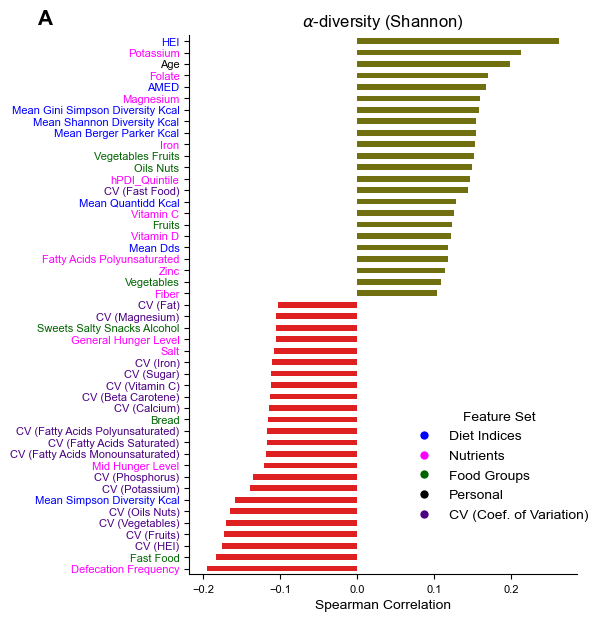

In [8]:
# Create visualization
fig, ax1 = plt.subplots(ncols=1, figsize=(5, 7))

# Create bar plot
sns.barplot(
    data=diversity_corr,
    y="feature",
    x="spearman",
    ax=ax1,
    width=0.5,
    palette=pos_neg_palette,
    hue="color",
    dodge=False,
)

# Customize plot appearance
ax1.set_title("$α$-diversity (Shannon)", fontsize=12, fontname="Arial")
ax1.set_ylabel("")
ax1.set_xlabel("Spearman Correlation", fontsize=10, fontname="Arial")
ax1.get_legend().remove()
ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=8, fontname="Arial")

# Customize y-axis labels
for label in ax1.get_yticklabels():
    label_text = label.get_text()
    label.set_color(ylabel_color_set[label_text])
    label.set_fontname("Arial")
    label.set_fontsize(8)

# Add legend
from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Diet Indices",
        markerfacecolor=ylabel_color_dict["Index"],
        markersize=7,
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Nutrients",
        markerfacecolor=ylabel_color_dict["Nutrient"],
        markersize=7,
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Food Groups",
        markerfacecolor=ylabel_color_dict["Food Group"],
        markersize=7,
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Personal",
        markerfacecolor=ylabel_color_dict["Personal"],
        markersize=7,
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="CV (Coef. of Variation)",
        markerfacecolor=ylabel_color_dict["CV"],
        markersize=7,
    ),
]

ax1.legend(
    handles=legend_elements,
    title="Feature Set",
    bbox_to_anchor=(0.8, 0.2),
    loc="center",
    frameon=False,
    fontsize=9,
    title_fontsize=10,
    prop={"family": "Arial"},
)

# Final plot adjustments
plt.setp(ax1.get_legend().get_title(), family="Arial")
ax1.text(-0.39, 1.02, "A", transform=ax1.transAxes, size=15, weight="bold")
sns.despine()

# Display plot
plt.show()

fig.savefig(
    "../../figures/gut_diversity_analysis/shannon_correlations.png",
    dpi=300,
    bbox_inches="tight",
)

## Gut Diversity Correlation Heatmap

In [9]:
def process_correlation(
    meta, target_col, ignore_cols=ignore_cols_noCV, corr_threshold=0.1
):
    """Calculate correlations for a target column and format the result."""
    return (
        target_col_best_corrs(
            meta, target_col, ignore_cols=ignore_cols, corr_threshold=corr_threshold
        )
        .to_frame(name=target_col)
        .reset_index(names=["feature"])
    )

In [10]:
# List of target columns to analyze
target_columns = ["shannon_entropy", "pielou_evenness", "faith_pd", "observed_features"]

# Generate correlation dataframes
correlation_dfs = [
    process_correlation(meta, target_col) for target_col in target_columns
]

# Merge all dataframes
microbe_diversity_corr = correlation_dfs[0]
for df in correlation_dfs[1:]:
    microbe_diversity_corr = microbe_diversity_corr.merge(df, on="feature", how="outer")

microbe_diversity_corr = microbe_diversity_corr.set_index("feature")
microbe_diversity_corr.sort_values(target_columns, ascending=False, inplace=True)
microbe_diversity_corr.shape

(56, 4)

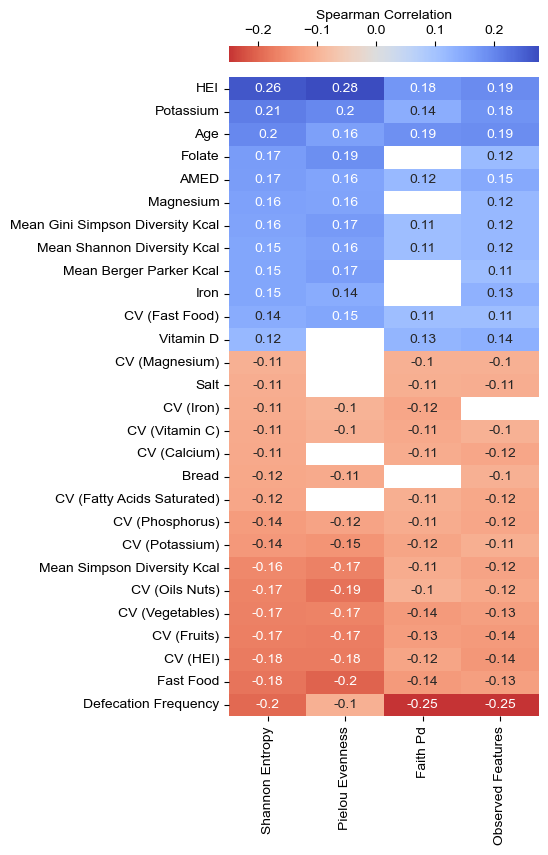

In [11]:
fig, ax = plt.subplots(figsize=(4, 10))
processed_labels = [
    process_string(label, newLineSep=None)
    for label in microbe_diversity_corr.dropna(thresh=3).index
]
sns.heatmap(
    microbe_diversity_corr.dropna(thresh=3),
    center=0,
    annot=True,
    cmap="coolwarm_r",
    yticklabels=processed_labels,
    xticklabels=[process_string(i, newLineSep=None) for i in target_columns],
    cbar_kws={
        "orientation": "horizontal",
        "pad": 0.02,
        "location": "top",
        "label": "Spearman Correlation",
    },
)

# ax.set_xlabel("Spearman Correlation", fontsize=10, fontname="Arial")
ax.set_ylabel("")

plt.savefig(
    "../../figures/gut_diversity_analysis/microbial_diversity_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

## Radar plot: HEI Q1 and Q4 intake comparison

In [5]:
def create_radar_plot(
    df,
    categories,
    quartile_col="HEI_Quartile",
    quartile_values=["Q1", "Q4"],
    colors=["#FF6B6B", "#4ECDC4"],
    figsize=(5, 5),
    radial_interval=100,
    max_radial_value=None,
):
    """
    Create a radar plot comparing dietary categories between different HEI quartiles.
    Categories are arranged by ascending median difference between Q4 and Q1.
    """
    df = df.copy()

    # Calculate median values for each category by quartile
    medians = {q: {} for q in quartile_values}
    median_differences = {}

    for cat in categories:
        for q in quartile_values:
            medians[q][cat] = df[df[quartile_col] == q][cat].median()
        # Calculate difference (Q4 - Q1)
        median_differences[cat] = medians["Q4"][cat] - medians["Q1"][cat]

    # Sort categories based on median differences
    sorted_categories = sorted(categories, key=lambda x: median_differences[x])

    # Calculate ordered median values for plotting
    means = {q: [] for q in quartile_values}
    for q in quartile_values:
        for cat in sorted_categories:
            means[q].append(medians[q][cat])

    # Number of variables
    num_vars = len(sorted_categories)

    # Compute angle for each axis
    angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
    angles += angles[:1]  # Complete the circle

    # Initialize the figure
    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(projection="polar"))

    # Plot data
    for i, quartile in enumerate(quartile_values):
        values = means[quartile]
        values += values[:1]  # Complete the circle

        ax.plot(
            angles,
            values,
            marker="o",
            linewidth=1,
            linestyle="--",
            label=f"Median {quartile}",
            color=colors[i],
        )
        ax.fill(
            angles,
            values,
            alpha=0.25,
            color=colors[i],
        )

    # Fix axis to go in the right order and start at 12 o'clock
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Draw axis lines for each angle and label
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([process_string(i, newLineSep=1) for i in sorted_categories])

    # Set clean intervals for the radial axis
    if max_radial_value is None:
        r_min, r_max = ax.get_ylim()
        # Round up r_max to nearest interval
        r_max_rounded = np.ceil(r_max / radial_interval) * radial_interval
    else:
        r_max_rounded = max_radial_value

    # Create evenly spaced ticks from 0 to rounded max
    yticks = np.arange(0, r_max_rounded + radial_interval, radial_interval)
    # If max_radial_value is set, ensure we don't exceed it
    yticks = yticks[yticks <= r_max_rounded]

    ax.set_ylim(0, r_max_rounded)
    ax.set_yticks(yticks)

    # Format labels as whole numbers
    ax.set_yticklabels([f"{int(x)}" for x in yticks])

    # Reduce the size of the r-axis labels
    ax.tick_params(axis="y", labelsize=8)

    # Make grid lines lighter
    ax.grid(color="gray", alpha=0.2)

    # Add legend
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(0.2, 1.2),
        title="HEI Quartile",
        # frameon=False,
    )

    return fig, ax

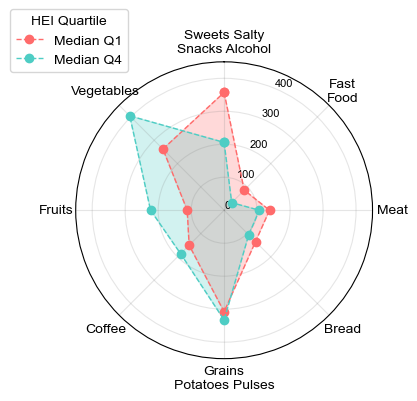

In [6]:
categories_for_radar = [
    "vegetables_fg_eaten",
    "fruits_fg_eaten",
    "grains_potatoes_pulses",
    "meat_fg_eaten",
    "sweets_salty_snacks_alcohol",
    "fast_food_fg_eaten",
    "bread_fg_eaten",
    "coffee_fg_eaten",
]

fig, ax = create_radar_plot(
    meta[meta["HEI_Quartile"].isin(["Q1", "Q4"])],
    categories_for_radar,
    radial_interval=100,
    max_radial_value=450,
    figsize=(4.2, 4.2),
)
plt.tight_layout()

plt.savefig(
    "../../figures/gut_diversity_analysis/HEI_Q1_Q4_intake_comparison.png",
    dpi=300,
    bbox_inches="tight",
)